In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sklearn

from keras.models import Sequential
from keras.layers import Dense, Activation
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.layers import Dense, InputLayer
from tensorflow.keras.models import Sequential
from sklearn.metrics import r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint)

In [11]:
df = pd.read_csv("rawdata_luftqualitaet.csv")
df[:5]

,humidity_inside,temperature_inside,co2_inside,temperature_heater,temperature_wall_inside,state_air_quality
0,58.94,21.955,1653,41.187,14.062,1
1,58.97,21.940,1665,40.937,14.062,1
2,57.89,22.353,1707,40.375,14.250,1
3,58.96,22.504,1981,40.875,14.375,1
4,57.74,22.515,1868,40.812,14.375,1


In [15]:
X = df.drop(columns='state_air_quality')
Y = df['state_air_quality']

display(X)
# display(Y)

,humidity_inside,temperature_inside,co2_inside,temperature_heater,temperature_wall_inside
0,58.94,21.955,1653,41.187,14.062
1,58.97,21.940,1665,40.937,14.062
2,57.89,22.353,1707,40.375,14.250
3,58.96,22.504,1981,40.875,14.375
4,57.74,22.515,1868,40.812,14.375
...,...,...,...,...,...
911,37.92,21.714,891,24.312,8.937
912,37.89,23.263,1165,52.250,10.062
913,39.82,23.043,1348,48.812,10.000
914,39.76,23.508,1470,51.375,10.312


In [ ]:


scaler_X = StandardScaler() # Merkmalsskalierung mit Standardscaler
X = scaler_X.fit_transform(X)
# scaler_y = StandardScaler() # Targetvektor wird auch skaliert
# Y = scaler_y.fit_transform(Y)

In [50]:
CATEGORIES = 3

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

c:\Users\Colin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_39 (Dense)                │ (None, 60)             │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 60)             │         3,660 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 3)              │           183 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,203 (16.42 KB)

 Trainable params: 4,203 (16.42 KB)

 Non-trainable params: 0 (0.00 B)

None

Epoch 1/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7801 - loss: 0.7818 - val_accuracy: 0.8587 - val_loss: 0.5050
Epoch 2/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8388 - loss: 0.4595 - val_accuracy: 0.8913 - val_loss: 0.3497
Epoch 3/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8989 - loss: 0.3481 - val_accuracy: 0.9076 - val_loss: 0.2806
Epoch 4/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9098 - loss: 0.2832 - val_accuracy: 0.9130 - val_loss: 0.2340
Epoch 5/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9085 - loss: 0.2391 - val_accuracy: 0.9022 - val_loss: 0.1998
Epoch 6/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9044 - loss: 0.2103 - val_accuracy: 0.9348 - val_loss: 0.1709
Epoch 7/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9262 - loss: 0.1827 - val_accuracy: 0.9457 - val_loss: 0.1477
Epoch 8/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9399 - loss: 0.1657 - val_accuracy: 0.9728 - v

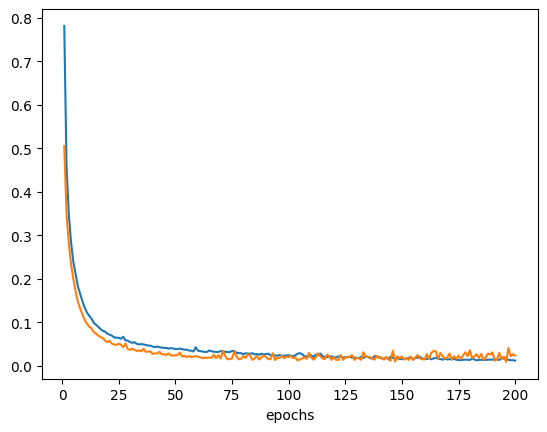

In [52]:

model = Sequential() 
model.add(InputLayer(input_shape=(5,)))
model.add(Dense(60, activation='relu'))
model.add(Dense(60, activation='relu'))
model.add(Dense(CATEGORIES, activation='softmax')) # softmax calculates the probabilities for the classes 
model.compile(
    # optimizer='sgd', # way less overfitting lol
    optimizer='adam',
    metrics=['accuracy'],
    # loss='binary_crossentropy'
    loss='sparse_categorical_crossentropy'
)

display(model.summary())

history = model.fit(x_train, y_train, epochs=200, batch_size=32, validation_data=(x_test, y_test))

loss_train = history.history['loss']
loss_test = history.history['val_loss']
plt.xlabel('epochs')
plt.plot(range(1, len(loss_train)+1), loss_train)
plt.plot(range(1, len(loss_test)+1), loss_test)


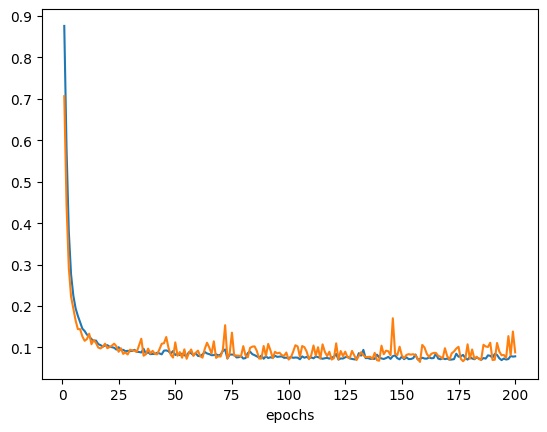

In [47]:
loss_train = history.history['loss']
loss_test = history.history['val_loss']
plt.xlabel('epochs')
plt.plot(range(1, len(loss_train)+1), loss_train)
plt.plot(range(1, len(loss_test)+1), loss_test)

# Aufgabe 2

c:\Users\Colin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


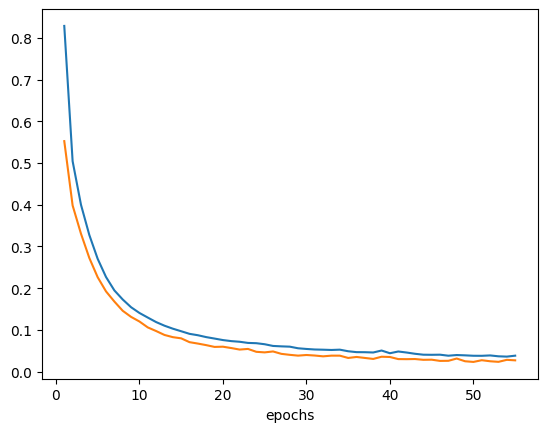

In [56]:

model = Sequential() 
model.add(InputLayer(input_shape=(5,)))
model.add(Dense(60, activation='relu'))
model.add(Dense(60, activation='relu'))
model.add(Dense(CATEGORIES, activation='softmax')) # softmax calculates the probabilities for the classes 
model.compile(
    # optimizer='sgd', # way less overfitting lol
    optimizer='adam',
    metrics=['accuracy'],
    # loss='binary_crossentropy'
    loss='sparse_categorical_crossentropy'
)

stopping = EarlyStopping(monitor='val_loss', patience=5)
checkpoint = ModelCheckpoint(filepath='keras_test_model.keras',
    monitor='val_loss',
    save_best_only=True)

history = model.fit(
    x_train, y_train, 
    epochs=200, batch_size=32, 
    validation_data=(x_test, y_test),
    callbacks=[stopping, checkpoint],
    verbose=False)

loss_train = history.history['loss']
loss_test = history.history['val_loss']
plt.xlabel('epochs')
plt.plot(range(1, len(loss_train)+1), loss_train)
plt.plot(range(1, len(loss_test)+1), loss_test)